# Lahore AQI — Exploratory Data Analysis

This notebook explores the aggregated hourly AQI feature data for Lahore,
pulled from the Feast offline feature store. The goal is to identify
temporal trends, understand feature distributions and relationships, and
surface data-quality characteristics that explain modeling decisions made
elsewhere in the pipeline (e.g. the chronological train/val/test split,
the `aqi_change_rate` staleness threshold).

All plotting logic lives in `eda_plots.py` this notebook only calls
those functions and adds narrative commentary. The same functions can
later be reused in the Streamlit dashboard without duplication.


In [18]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

import os
os.chdir("C:\\Users\\abuhu\\Desktop\\Internship\\AQI-Pearls-Predictor")
print(os.getcwd())

from feast_store import get_all_rows
import eda_plots as eda
from clean_backfill import clean

pd.set_option("display.max_columns", None)


C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor


## 1. Load the data

Pulling the full historical feature set from Feast (`get_all_rows()`),
which returns the same shape used by the training pipeline: `timestamp`
as epoch-ms int, plus `aqi`, `pm25`, `pm10`, `temperature`, `humidity`,
`aqi_change_rate`, `hour`, `day_of_week`, `month`.


In [19]:
df = get_all_rows()
print(f"{len(df)} raw rows loaded")

df = clean(df)
print(f"{len(df)} rows after cleaning (dedup + change-rate recompute)")

df.head()


C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\feast\repo_config.py:531: DeprecationWarning: The serialization version below 3 are deprecated. Specifying `entity_key_serialization_version` to 3 is recommended.
  warnings.warn(


196 raw rows loaded
180 rows after cleaning (dedup + change-rate recompute)


,timestamp,aqi,pm25,pm10,temperature,humidity,aqi_change_rate,hour,day_of_week,month,rate_gap_hours
0,1787961667000,173.357218,173.357218,87.349091,30.6,63.0,NaN,0,5,8,NaN
1,1787965278000,125.376884,125.376884,52.989697,31.0,62.0,-47.834174,1,5,8,1.003056
2,1787968850000,156.369863,156.369863,66.180101,32.3,59.0,31.235925,2,5,8,0.992222
3,1787972481000,106.170854,106.170854,45.259259,33.8,52.0,-49.770430,3,5,8,1.008611
4,1787976039000,98.738197,98.738197,41.888889,34.8,49.0,-7.520395,4,5,8,0.988333


In [20]:
df.describe(include="all")


,timestamp,aqi,pm25,pm10,temperature,humidity,aqi_change_rate,hour,day_of_week,month,rate_gap_hours
count,1.800000e+02,180.000000,180.000000,180.000000,180.000000,180.000000,178.000000,180.000000,180.000000,180.000000,179.000000
mean,1.788285e+12,114.922460,114.856188,46.798007,33.010056,52.913889,0.583787,11.022222,3.144444,8.600000,1.011209
std,1.886529e+08,25.942168,25.931542,14.040957,2.212399,7.652515,18.766444,6.873929,2.008702,0.491264,0.246674
min,1.787962e+12,32.083333,32.083333,0.000000,25.300000,34.000000,-49.770430,0.000000,0.000000,8.000000,0.052409
25%,1.788123e+12,96.384661,96.310849,38.107784,31.275000,48.000000,-6.594358,5.000000,1.000000,8.000000,0.993472
50%,1.788284e+12,116.185247,115.910931,47.900363,32.847500,53.250000,0.736893,11.000000,3.000000,9.000000,1.000000
75%,1.788445e+12,131.040201,131.040201,54.308737,34.700000,58.000000,5.871351,17.000000,5.000000,9.000000,1.006528
max,1.788613e+12,186.885142,186.885142,104.712121,37.745000,86.000000,147.684290,23.000000,6.000000,9.000000,3.620753


**What to look for here:** row count (how much history you actually
have), obvious out-of-range values, and how many nulls exist in
`aqi_change_rate` (expected — cold-start row plus any gap exceeding the
3h staleness threshold).


## 2. Temporal patterns

### 2.1 Full AQI history

The background shading marks EPA AQI hazard categories (Good → Hazardous),
so it's easy to see at a glance how much of Lahore's AQI history sits in
"Unhealthy" territory or worse.


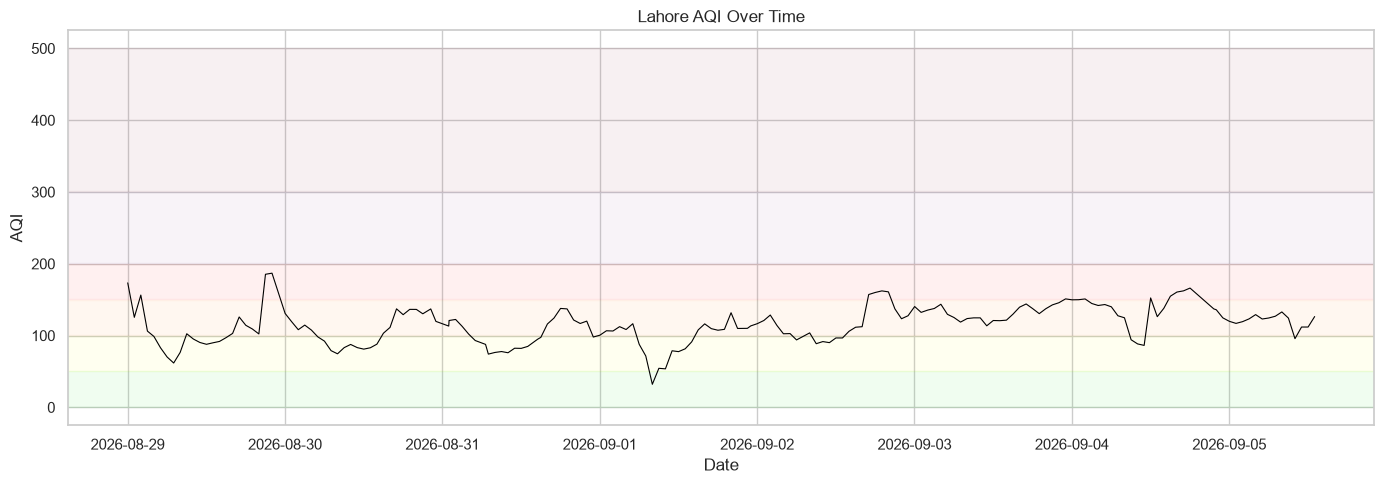

In [21]:
fig = eda.plot_aqi_timeseries(df)
plt.show()


*Commentary: note whether AQI trends upward/downward over the
collection window, and whether spikes correlate with anything observable
(e.g. weekends, specific months, missing-data gaps right before/after a
spike).*


### 2.2 Diurnal pattern (hour of day)

Air quality in cities driven by traffic and industrial activity often
shows a bimodal pattern — worse during morning/evening rush hours, better
overnight and midday.


C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


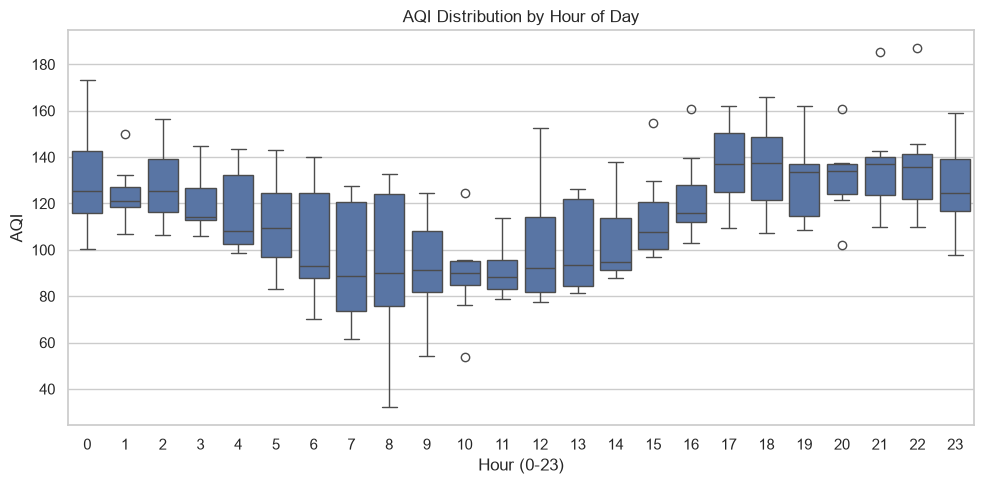

In [22]:
fig = eda.plot_hourly_pattern(df)
plt.show()


### 2.3 Day-of-week pattern

C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


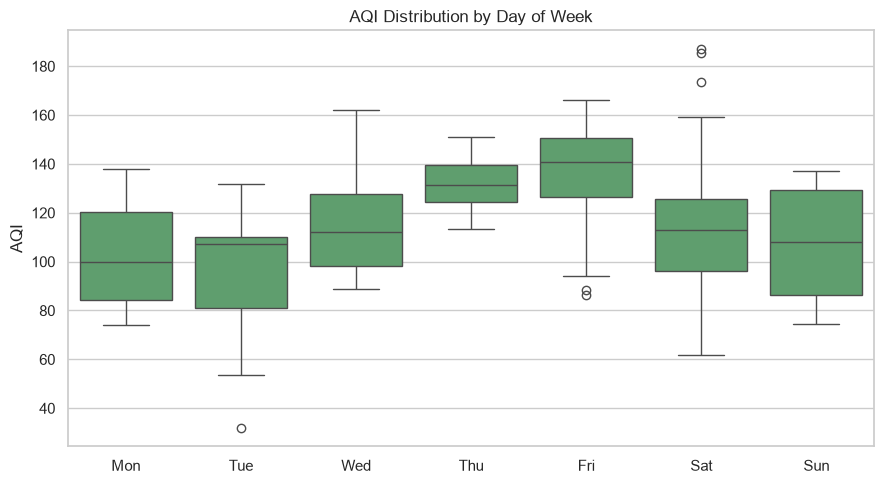

In [23]:
fig = eda.plot_weekly_pattern(df)
plt.show()


*Commentary: is there a visible weekday/weekend effect (e.g. lower
traffic-driven pollution on weekends)? If the boxplots look nearly
identical across days, that's worth noting too — it means `day_of_week`
may contribute less signal to the model than `hour` does.*


### 2.4 Monthly pattern

Only meaningful once your collection window spans multiple months —
otherwise this will show a single box.


C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


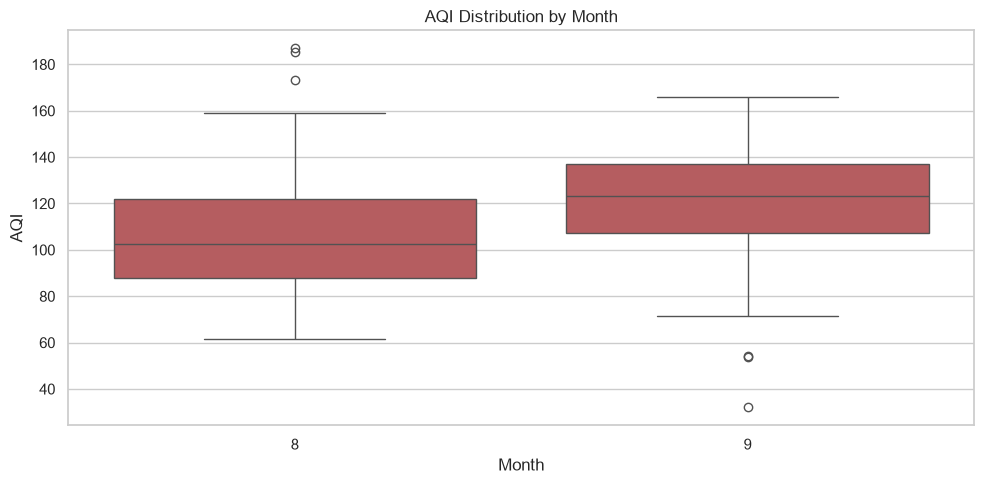

In [24]:
fig = eda.plot_monthly_pattern(df)
plt.show()


## 3. Distributions

### 3.1 AQI distribution

Skewness matters here: AQI is bounded below at 0 and can spike sharply
upward during pollution events, so a right-skewed distribution is
expected rather than a bug.


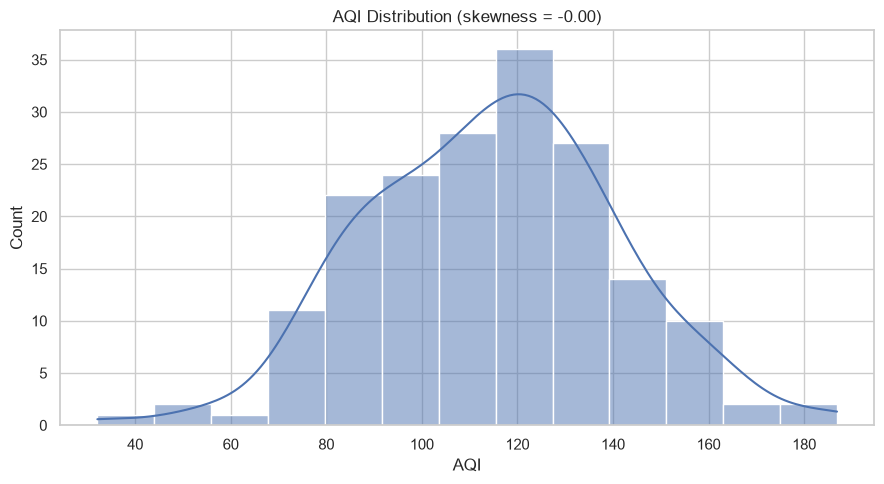

In [25]:
fig = eda.plot_aqi_distribution(df)
plt.show()


### 3.2 Pollutant distributions (PM2.5 / PM10)

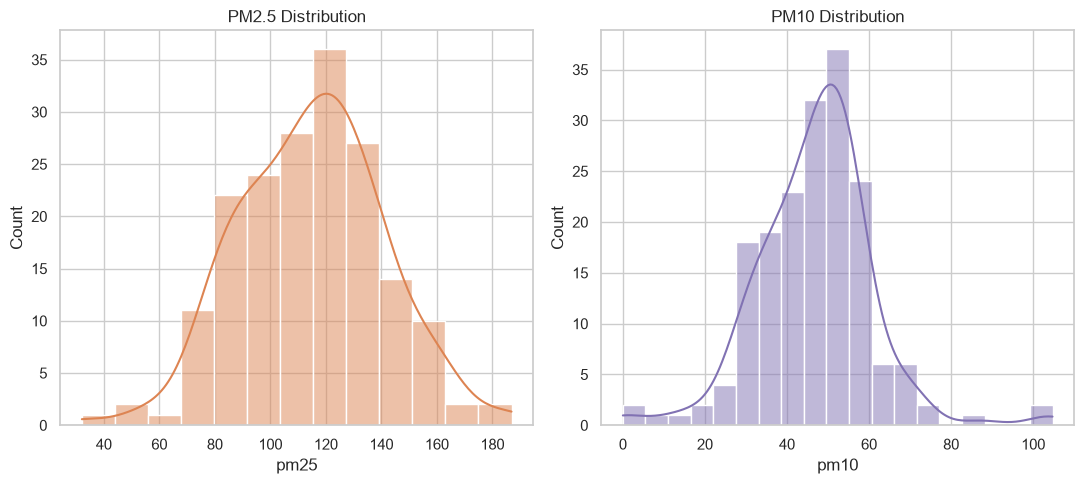

In [26]:
fig = eda.plot_pollutant_distributions(df)
plt.show()


## 4. Relationships between features

### 4.1 Correlation heatmap

This sets expectations for the SHAP analysis later: whichever features
correlate most strongly with AQI here should generally show up as
high-impact features in SHAP's global importance ranking. If they don't
match, that discrepancy is worth investigating rather than ignoring.


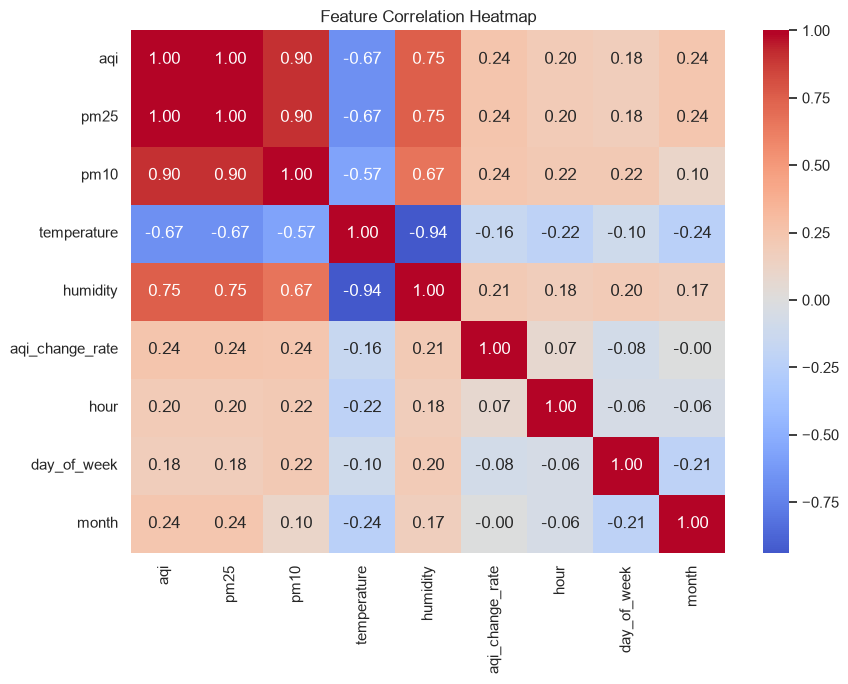

In [27]:
fig = eda.plot_correlation_heatmap(df)
plt.show()


### 4.2 AQI vs. PM2.5 / PM10

Since AQI is computed from pollutant concentrations, a clear positive
relationship here is a sanity check that the data pipeline is behaving
correctly — not a novel finding.


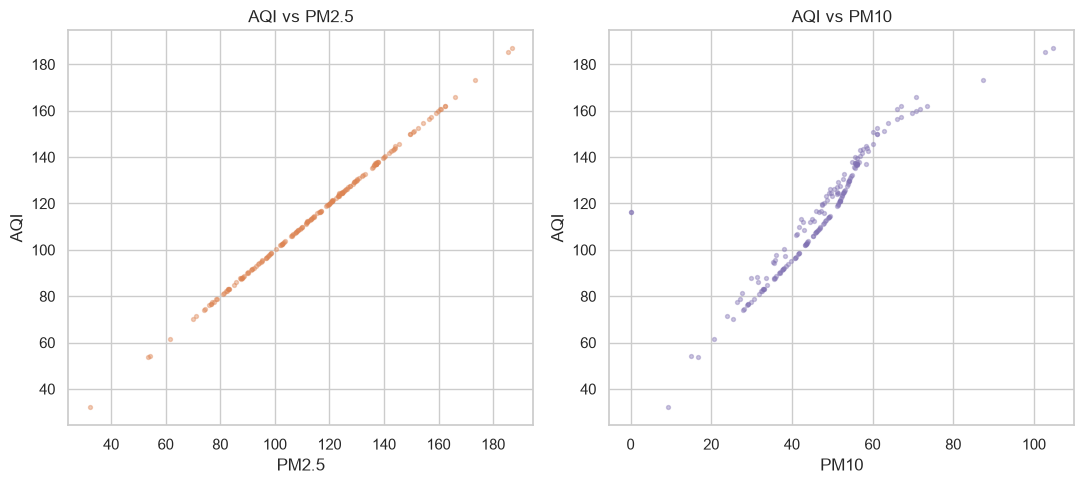

In [28]:
fig = eda.plot_aqi_vs_pm(df)
plt.show()


### 4.3 AQI change rate distribution

This is the **raw** Feast feature (nulls included, not the zero-imputed
version `train.py` feeds to the models). The shape of this distribution
around zero tells you how volatile AQI typically is hour-to-hour.


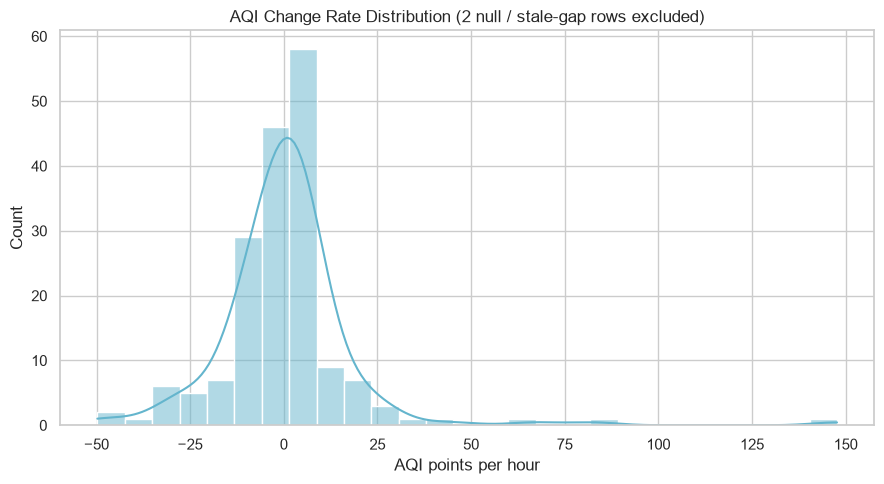

In [29]:
fig = eda.plot_change_rate_distribution(df)
plt.show()


## 5. Data quality

### 5.1 Missingness / gaps over time

Expected gap between consecutive rows is 1 hour (hourly fetch cadence).
Spikes above the dashed reference line indicate missed fetch cycles,
stale-data exclusions during validation, or GitHub Actions runner issues.


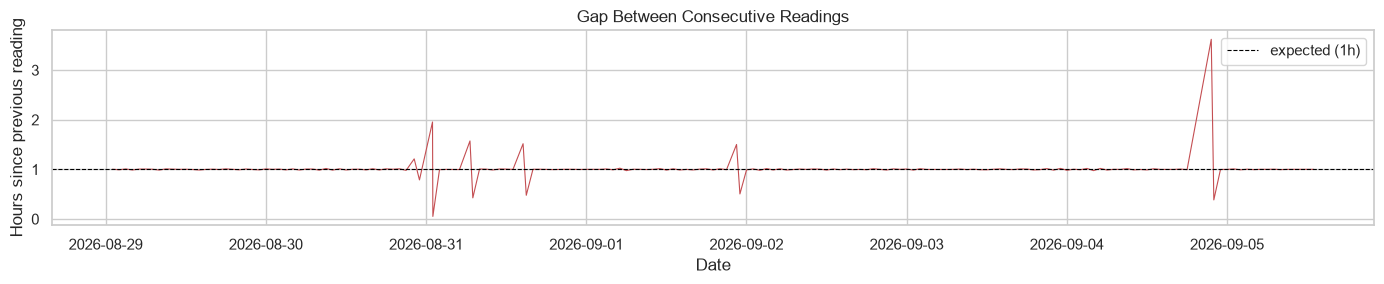

In [30]:
fig = eda.plot_missingness_over_time(df)
plt.show()


### 5.2 Train / validation / test split variance

This directly visualizes the reasoning behind the project's known
low-test-R² finding: if the chronological test window happens to fall in
a period of narrower AQI variance than train, R² will look poor even
though RMSE (the primary metric used here) remains reasonable.


C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\notebooks\..\eda_plots.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="split", y="aqi", order=["train", "val", "test"], ax=ax,
C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predicto

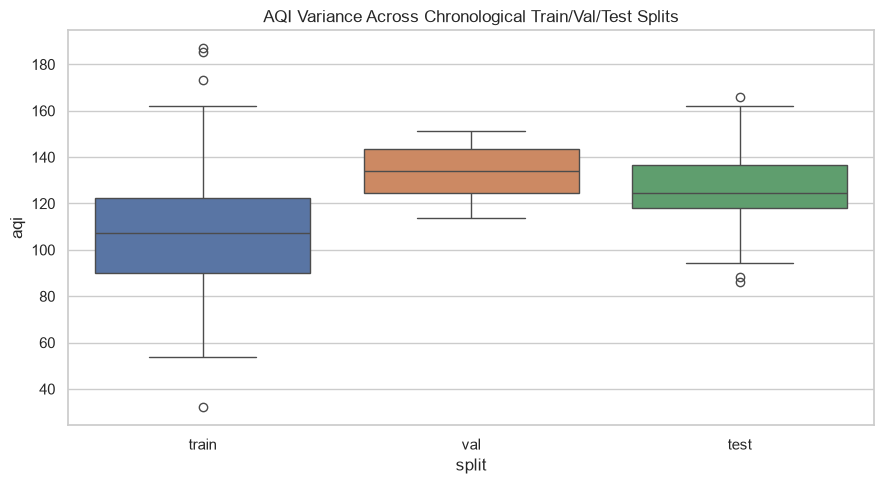

In [31]:
fig = eda.plot_train_val_test_variance(df)
plt.show()


## 6. Summary of findings

### Row count / history span:
Out of 196 rows only 180 were unique hourly readings

On average the AQI of Lahore is 114 which is already unhealthy, mostly for sensitive people. With a std of 25 which means at mostly stays in the moderate to unhealthy bands
At max according to last few days the max it has reached is 186 which unhealthy even for non sensitive people. Any more and it would be hazardous to stay in the city
### Diurnal / weekly / monthly patterns observed:
Over the course of the day, you can see a noticeable dip in aqi during the mid day which is expected due to sunlight and wind and a rise during the night due to increase traffic in the afternoon and reduced boundary layer height which traps the emissions near the surface

You see an increase aqi trend on Thursdays and Fridays and lower Mondays and Sundays probably due to decrease traffic activity

The AQI distribution is right skewed because of the bad but still non extremely hazardous levels of aqi in Lahore. AQI values tend to stay closer to 0 which is the normal behaviour
### Distribution shape notes (skewness, outliers):
PM2.5 which is primarily the pollutant in Lahore has similar distribution to aqi(expected)
PM10 is right skewed which is the expected distribution.
### Correlation highlights (strongest AQI drivers):
Heavy correlation between pm2.5, pm10 and aqi values. Expected because the pollutant values are related and show pollutants in a city and aqi is simply the maximum of those values. After that AQI is heavily related to humidity and after that temperature is also related to aqi
### Data quality issues found (gaps, stale periods):
Some gaps in the data due to GitHub actions and hopsworks materialization problems and also a big gap at the end while switching with feast
### How train/val/test variance explains the R² behavior:
High variation in the train part. Slightly lower variation in the validation and test splits. Primarily because of the gap filled by openaq. It was necessary tho. But it explains the bad R²